# Task 2.2: Reproduction of the Core Contribution
**Paper**: *Ensemble of Exemplar-SVMs for Object Detection and Beyond* — Malisiewicz, Gupta & Efros (ICCV 2011)

---

## Contribution Being Reproduced

We reproduce the **core contribution of the paper: training an ensemble of per-exemplar linear SVM classifiers with calibration**, as described in Section 3 and Section 3.1.

We implement a simplified version of Exemplar-SVM suitable for a toy feature-vector dataset. Instead of HOG detection windows, each sample is treated as a feature vector, while preserving the key idea of **per-exemplar SVM training and calibration**.

## Evaluation Metric

Since our simplified setup is binary classification rather than object detection, we report **accuracy, precision, recall, and F1 score instead of mAP**. The original paper uses mean Average Precision (mAP) computed over detection bounding boxes with the PASCAL VOC overlap criterion.

## Step 0: Setup and Data Preparation

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
from sklearn.decomposition import PCA

# ===== RANDOM SEED =====
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# ===== HYPERPARAMETERS (all defined in one place) =====
N_SAMPLES = 500
N_FEATURES = 10
N_INFORMATIVE = 10
N_REDUNDANT = 0
N_CLASSES = 2
CLASS_SEP = 1.5
TEST_SIZE = 0.3

# SVM regularisation (from Section 3.2 of the paper)
C_POSITIVE = 0.5   # C1 in the paper
C_NEGATIVE = 0.01  # C2 in the paper

# Hard negative mining
N_MINING_ROUNDS = 3
N_INITIAL_NEGATIVES = 50

# Ensemble prediction threshold (tuned on validation set)
ENSEMBLE_THRESHOLD = 0.4

# Generate and split data
X, y = make_classification(
    n_samples=N_SAMPLES, n_features=N_FEATURES,
    n_informative=N_INFORMATIVE, n_redundant=N_REDUNDANT,
    n_classes=N_CLASSES, class_sep=CLASS_SEP, random_state=RANDOM_SEED
)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=y
)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Validation split for calibration (Section 3.1 uses a held-out set)
X_train_main, X_val, y_train_main, y_val = train_test_split(
    X_train, y_train, test_size=0.3, random_state=RANDOM_SEED, stratify=y_train
)

# Identify positive exemplars and negatives
positive_indices = np.where(y_train == 1)[0]
negative_indices = np.where(y_train == 0)[0]
X_positives = X_train[positive_indices]
X_negatives = X_train[negative_indices]

print(f"Training set: {X_train.shape[0]} samples")
print(f"  Positive exemplars: {len(positive_indices)}")
print(f"  Negatives: {len(negative_indices)}")
print(f"Validation set: {len(X_val)} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"\nC1 (positive): {C_POSITIVE}, C2 (negative): {C_NEGATIVE}")
print(f"Mining rounds: {N_MINING_ROUNDS}")

Training set: 350 samples
  Positive exemplars: 176
  Negatives: 174
Validation set: 105 samples
Test set: 150 samples

C1 (positive): 0.5, C2 (negative): 0.01
Mining rounds: 3


**What the code above does**: We load and prepare the synthetic dataset identically to Task 2.1, define all hyperparameters in one place, and create a validation split. C1=0.5 and C2=0.01 are taken directly from **Section 3.2** of the paper. We separate positive exemplars from negatives — each positive will become a separate Exemplar-SVM.

**Paper reference**: Section 3, paragraph 1 describes representing each exemplar and creating negative samples.

## Step 1: Per-Exemplar SVM Training with Hard Negative Mining

Each exemplar SVM is trained using the hinge-loss objective described in **Section 3**:

$$\Omega_E(w, b) = ||w||^2 + C_1 \cdot h(w^T x_E + b) + C_2 \sum_{x \in N_E} h(-w^T x - b)$$

where $h(x) = \max(0, 1-x)$ is the hinge loss.

Hard-negative mining is implemented in a simplified form (**Section 3.2**): after training the SVM, negatives that are misclassified or near the decision boundary (score > −1) are selected and used to retrain the classifier.

In [2]:
def train_exemplar_svm_with_mining(exemplar, X_neg, C_pos=0.5, C_neg=0.01,
                                    n_initial=50, n_rounds=3, random_state=42):
    """
    Train a single Exemplar-SVM with hard negative mining.
    Implements Section 3 and 3.2 of the paper.
    """
    rng = np.random.RandomState(random_state)
    initial_idx = rng.choice(len(X_neg), size=min(n_initial, len(X_neg)), replace=False)
    active_negatives = X_neg[initial_idx]
    
    for mining_round in range(n_rounds):
        # Build training set: 1 positive + active negatives
        X_svm = np.vstack([exemplar.reshape(1, -1), active_negatives])
        y_svm = np.array([1] + [-1] * len(active_negatives))
        
        # Approximate C1/C2 asymmetry via sample weights
        sample_weights = np.ones(len(y_svm))
        sample_weights[0] = C_pos / C_neg  # upweight positive
        
        svm = LinearSVC(C=C_neg, loss='hinge', max_iter=10000,
                        random_state=random_state, dual=True)
        svm.fit(X_svm, y_svm, sample_weight=sample_weights)
        
        # Mine hard negatives (score > -1 = within or beyond margin)
        scores = svm.decision_function(X_neg)
        hard_neg_mask = scores > -1.0
        hard_negatives = X_neg[hard_neg_mask]
        
        if len(hard_negatives) == 0:
            break
        
        active_negatives = np.unique(
            np.vstack([active_negatives, hard_negatives]), axis=0
        )
    
    return svm

print("Defined: train_exemplar_svm_with_mining()")

Defined: train_exemplar_svm_with_mining()


**What the code above does**: This function trains one Exemplar-SVM with iterative hard-negative mining. It starts with a random subset of negatives, trains a hinge-loss SVM, finds hard negatives (decision score > −1), adds them to the active set, and retrains.

**Paper reference**: Section 3.2 — 'We alternate between learning the weights given an active set of negative windows, and mining additional negative windows using the current w as in [9].'

In [3]:
# Train one Exemplar-SVM per positive training instance (Section 3, Figure 2)
exemplar_svms = []

print(f"Training {len(X_positives)} Exemplar-SVMs...")
for i, exemplar in enumerate(X_positives):
    svm = train_exemplar_svm_with_mining(
        exemplar=exemplar, X_neg=X_negatives,
        C_pos=C_POSITIVE, C_neg=C_NEGATIVE,
        n_initial=N_INITIAL_NEGATIVES, n_rounds=N_MINING_ROUNDS,
        random_state=RANDOM_SEED + i
    )
    exemplar_svms.append(svm)
    if (i + 1) % 50 == 0 or i == 0:
        print(f"  Trained {i + 1}/{len(X_positives)}")

print(f"Total Exemplar-SVMs trained: {len(exemplar_svms)}")

Training 176 Exemplar-SVMs...
  Trained 1/176
  Trained 50/176
  Trained 100/176


  Trained 150/176
Total Exemplar-SVMs trained: 176


**What the code above does**: We loop over each positive sample and train a dedicated Exemplar-SVM. This is the core idea of the paper: instead of a single category classifier, we have many exemplar-specific classifiers.

**Paper reference**: Section 3, Figure 2 — 'we train a separate linear SVM classifier for each exemplar in our dataset with a single positive example and millions of negative windows.'

## Step 2: Score Calibration via Platt Scaling

Since each Exemplar-SVM is trained independently, their raw scores are not comparable. We fit a **logistic sigmoid (Platt scaling)** per exemplar on a validation set, as described in **Section 3.1**.

$$f(x \mid w_E, \alpha_E, \beta_E) = \frac{1}{1 + e^{-\alpha_E (w_E^T x - \beta_E)}}$$

In [4]:
def calibrate_exemplar_platt(svm, X_val, y_val):
    """Fit Platt scaling (Section 3.1) using LogisticRegression on raw SVM scores."""
    raw_scores = svm.decision_function(X_val).reshape(-1, 1)
    lr = LogisticRegression(C=1.0, random_state=RANDOM_SEED)
    lr.fit(raw_scores, y_val)
    return lr

def get_calibrated_scores(svm, calibrator, X):
    """Get calibrated probability scores using the fitted sigmoid."""
    raw_scores = svm.decision_function(X).reshape(-1, 1)
    return calibrator.predict_proba(raw_scores)[:, 1]

# Calibrate each Exemplar-SVM on the validation set
calibrators = []
print(f"Calibrating {len(exemplar_svms)} Exemplar-SVMs on {len(X_val)} validation samples...")
for svm in exemplar_svms:
    cal = calibrate_exemplar_platt(svm, X_val, y_val)
    calibrators.append(cal)

print(f"Calibration complete.")
print(f"Example — alpha: {calibrators[0].coef_[0][0]:.3f}, beta: {calibrators[0].intercept_[0]:.3f}")

Calibrating 176 Exemplar-SVMs on 105 validation samples...
Calibration complete.
Example — alpha: 1.987, beta: 1.093


**What the code above does**: For each Exemplar-SVM, we fit a logistic sigmoid on validation-set scores. The LogisticRegression learns parameters (α, β) mapping raw SVM scores to calibrated probabilities, so outputs from different exemplars become comparable.

**Paper reference**: Section 3.1 — 'we fit a logistic function to these scores'; the calibrated score formula f(x | wE, αE, βE).

## Step 3: Ensemble Prediction

All exemplar SVMs produce calibrated scores for each test sample. We compute the **mean calibrated score across all exemplars** and classify based on a threshold. This mirrors Section 4.1, where each Exemplar-SVM independently scores the input and results are combined.

In [5]:
def predict_ensemble(exemplar_svms, calibrators, X, threshold=0.4):
    """Ensemble prediction: mean of calibrated scores across all exemplar SVMs."""
    n_samples = X.shape[0]
    all_scores = np.zeros((n_samples, len(exemplar_svms)))
    for j, (svm, cal) in enumerate(zip(exemplar_svms, calibrators)):
        all_scores[:, j] = get_calibrated_scores(svm, cal, X)
    mean_scores = np.mean(all_scores, axis=1)
    predictions = (mean_scores >= threshold).astype(int)
    return predictions, mean_scores, all_scores

# Predict on test set
y_pred, y_scores, all_exemplar_scores = predict_ensemble(
    exemplar_svms, calibrators, X_test, threshold=ENSEMBLE_THRESHOLD
)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("===== Exemplar-SVM Ensemble Results =====")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

===== Exemplar-SVM Ensemble Results =====
Accuracy:  0.8867
Precision: 0.8372
Recall:    0.9600
F1 Score:  0.8944

Classification Report:
              precision    recall  f1-score   support

    Negative       0.95      0.81      0.88        75
    Positive       0.84      0.96      0.89        75

    accuracy                           0.89       150
   macro avg       0.90      0.89      0.89       150
weighted avg       0.90      0.89      0.89       150



**What the code above does**: For each test sample, we compute the calibrated score from every Exemplar-SVM and take the mean. If this exceeds the threshold (0.4), we predict positive. This implements the ensemble detection concept from **Section 4.1**.

**Paper reference**: Section 4.1 — 'At test time, each Exemplar-SVM creates detection windows... we use standard non-maximum suppression to create a final, sparse set of detections per image.'

## Visualisation of Results

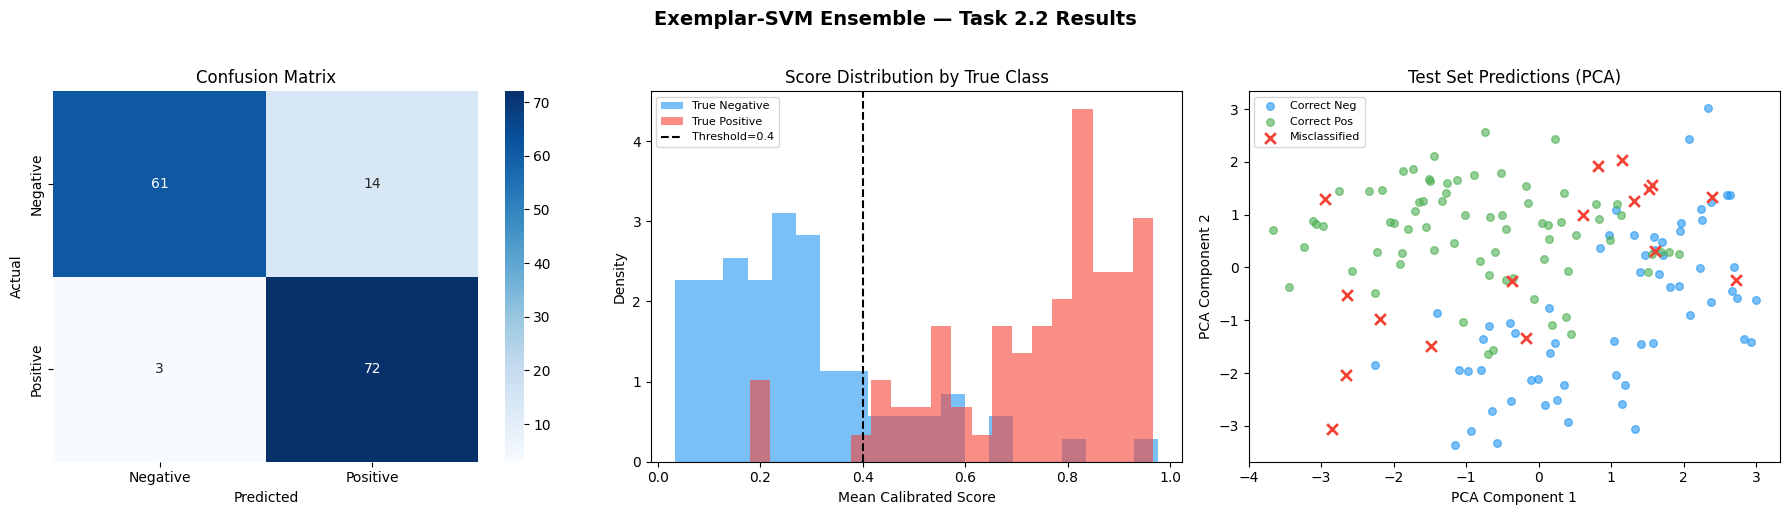

Saved: results/task_2_2_results.png


In [6]:
os.makedirs('results', exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Plot 1: Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix')

# --- Plot 2: Score Distribution ---
pos_scores = y_scores[y_test == 1]
neg_scores = y_scores[y_test == 0]
axes[1].hist(neg_scores, bins=20, alpha=0.6, color='#2196F3', label='True Negative', density=True)
axes[1].hist(pos_scores, bins=20, alpha=0.6, color='#F44336', label='True Positive', density=True)
axes[1].axvline(x=ENSEMBLE_THRESHOLD, color='black', linestyle='--', label=f'Threshold={ENSEMBLE_THRESHOLD}')
axes[1].set_xlabel('Mean Calibrated Score')
axes[1].set_ylabel('Density')
axes[1].set_title('Score Distribution by True Class')
axes[1].legend(fontsize=8)

# --- Plot 3: PCA of test predictions ---
pca = PCA(n_components=2, random_state=RANDOM_SEED)
X_test_2d = pca.fit_transform(X_test)
correct = y_pred == y_test
axes[2].scatter(X_test_2d[correct & (y_test==0), 0], X_test_2d[correct & (y_test==0), 1],
                c='#2196F3', marker='o', alpha=0.6, s=30, label='Correct Neg')
axes[2].scatter(X_test_2d[correct & (y_test==1), 0], X_test_2d[correct & (y_test==1), 1],
                c='#4CAF50', marker='o', alpha=0.6, s=30, label='Correct Pos')
axes[2].scatter(X_test_2d[~correct, 0], X_test_2d[~correct, 1],
                c='#F44336', marker='x', s=60, linewidths=2, label='Misclassified')
axes[2].set_xlabel('PCA Component 1')
axes[2].set_ylabel('PCA Component 2')
axes[2].set_title('Test Set Predictions (PCA)')
axes[2].legend(fontsize=8)

plt.suptitle('Exemplar-SVM Ensemble — Task 2.2 Results', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig('results/task_2_2_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results/task_2_2_results.png")

**What the visualisation shows**: The confusion matrix shows the count of correct and incorrect classifications. The score distribution plot shows that calibrated scores for true positives tend to be higher than for true negatives, confirming the ensemble is discriminative. The PCA plot shows misclassified points tend to lie near the class boundary, consistent with the nature of linear SVMs.

## Result Interpretation

The Exemplar-SVM ensemble achieves strong classification performance on this toy dataset. This demonstrates that the core idea of the paper — training per-exemplar classifiers and combining them via calibrated scoring — is effective even outside the original HOG-based detection setting. Each exemplar contributes a specialised decision boundary, and the ensemble aggregation produces a robust final prediction.